<a href="https://colab.research.google.com/github/ksshah/seed-and-scale/blob/main/Barley_Water_Risk_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thirsty Crops — Barley Water-Risk Simulator (Datathon Build)

Implements the **Proposed Solution** from the Aug 25 problem statement, on top of the validated
FAOSTAT bulk-download pipeline from `Kaveesha_seed_and_scale_fixed.ipynb` (production concentration +
SDG 6.4.2 water stress — the dtype-cast and aggregate-filter fixes from that notebook are carried
over here).

Scope is narrowed to **Barley only**, per the finalized brief (the earlier notebook's open question
about widening to wheat/rice/soy is now settled — Layer 1 is barley-only for this build).

| Brief step | Section here |
|---|---|
| 0. Data principles | Section 0 |
| 1. Validate central finding (production × water stress) | Sections 1–4 |
| 2. Quantify trade exposure | Sections 5–6 |
| 3. Prototype scenario (shock + diversification) | Section 7 |
| AI-written resilience brief | Section 8 |

Self-contained — run top to bottom in a fresh Colab/Jupyter runtime. Bulk downloads total roughly
1–2GB (the trade matrix file is the big one); first run will take a few minutes, mostly on that
download.


## Section 0: Setup

In [1]:
# Section 0: Setup
import urllib.request, zipfile, io, os, json, textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)


## Section 0: Data principles

Decisions that shape every downstream number — written down before joining anything, per the
brief's Step 0 ("Define data principles: years of analysis, crops, imputations/exclusions").

In [2]:
# Section 0: Data principles, encoded as config so every downstream calc references the same
# assumptions instead of re-deciding them inline.
CONFIG = {
    # --- Scope ---
    'crop_item_code': 44,        # FAOSTAT Item Code for Barley (verified in Section 1)
    'crop_name': 'Barley',

    # --- Years ---
    # Single-year production/trade figures are noisy (one bad harvest, one reporting gap).
    # Use a trailing N-year average, anchored to the latest year with broad country coverage,
    # for anything used to rank/classify countries. Time-series charts still use the full history.
    'trailing_avg_years': 3,

    # --- Water stress (SDG 6.4.2: freshwater withdrawal as % of available freshwater resources) ---
    # UN-Water / FAO AQUASTAT tiers. FAOSTAT's SDG bulk file gives each country one number per year
    # it reported, and reporting is patchy (see Section 3). We take the LATEST available value per
    # country rather than a fixed reference year, and carry the source year alongside every value so
    # it stays visible in every table/chart instead of being silently smoothed away.
    'water_stress_bins':   [0, 25, 50, 75, 100, float('inf')],
    'water_stress_labels': ['No stress', 'Low stress', 'Medium stress', 'High stress', 'Critical'],
    # "Meaningfully water-stressed" for the exposure flags below = UN-Water's own threshold for
    # entering water stress at all (>=25%). The full 5-tier breakdown is still kept for nuance.
    'stress_threshold_pct': 25,

    # --- Scope of "major producer" / "major supplier" ---
    'top_n_producers': 15,        # shortlist for the production x water-stress cross (Section 4)
    'top_n_importers_display': 15,

    # --- Imputation / exclusion rules ---
    # - Drop FAOSTAT regional/continental aggregates (Area/Reporter/Partner Code >= 5000) everywhere
    #   — same bug class the original notebook's Section 3 flagged and fixed.
    # - Never impute a missing water-stress value; a supplier with no SDG 6.4.2 reading is labeled
    #   'No data' and excluded from the %-from-stressed-suppliers calc (flagged separately, not
    #   silently dropped or assumed safe).
    # - The scenario simulator (Section 7) assumes shock elasticity = 1 (a 10% cut in a supplier's
    #   production is modeled as a 10% cut in that supplier's exports) and unconstrained reallocation
    #   headroom for diversification. Both are simplifications — restated in Section 9.
}

# Caveat repeated throughout the brief: FAOSTAT does not separate brewing barley from feed/food
# barley. Every number in this notebook is total barley; beer is the storytelling frame, not the
# analytical scope.
print(json.dumps({k: v for k, v in CONFIG.items() if k != 'water_stress_bins'}, indent=2, default=str))


{
  "crop_item_code": 44,
  "crop_name": "Barley",
  "trailing_avg_years": 3,
  "water_stress_labels": [
    "No stress",
    "Low stress",
    "Medium stress",
    "High stress",
    "Critical"
  ],
  "stress_threshold_pct": 25,
  "top_n_producers": 15,
  "top_n_importers_display": 15
}


## Section 1: Barley production — QCL bulk download

Reuses the fixed bulk-download + item-code-verification + country-filter logic from the earlier
notebook (its Sections 1–3), scoped to Barley only.

In [3]:
# Section 1a: QCL bulk download (Production: Crops and livestock products)
BULK_URL = 'https://bulks-faostat.fao.org/production/Production_Crops_Livestock_E_All_Data_(Normalized).zip'
if not os.path.exists('qcl_bulk.zip'):
    print('Downloading QCL bulk file...')
    urllib.request.urlretrieve(BULK_URL, 'qcl_bulk.zip')

with zipfile.ZipFile('qcl_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    print(f'Reading {csv_name}...')
    qcl_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)

    item_csv = [n for n in z.namelist() if 'ItemCodes' in n][0]
    item_codes = pd.read_csv(z.open(item_csv), encoding='latin-1')

    area_csv = [n for n in z.namelist() if 'AreaCodes' in n][0]
    area_codes = pd.read_csv(z.open(area_csv), encoding='latin-1')

print(f'Full QCL: {len(qcl_all):,} rows')


Reading Production_Crops_Livestock_E_All_Data_(Normalized).csv...
Full QCL: 4,209,110 rows


In [5]:
# Section 1b: verify the Barley item code before trusting it — same discipline as the original
# notebook's Section 2 (codes get hardcoded once and then never re-checked otherwise).
# Don't assume the code is 44: derive it from this file's own lookup table, the same way
# Section 5b does for the trade domain, rather than asserting against a hardcoded guess.
barley_matches = item_codes[item_codes['Item'].str.contains('Barley', case=False, na=False)][['Item Code', 'Item']]
print(barley_matches.to_string(index=False))

exact = barley_matches[barley_matches['Item'].str.fullmatch('Barley', case=False)]
if len(exact):
    CONFIG['crop_item_code'] = int(exact.iloc[0]['Item Code'])
else:
    print("No exact 'Barley' match in the lookup — check the table above and set CONFIG['crop_item_code'] manually.")
    CONFIG['crop_item_code'] = int(barley_matches.iloc[0]['Item Code'])  # best-effort fallback

print(f"Using Item Code {CONFIG['crop_item_code']} for Barley")

Item Code                   Item
       44                 Barley
       51 Beer of barley; malted
Using Item Code 44 for Barley


In [6]:
# Section 1c: filter to Barley Production (tonnes), then drop regional/continental aggregates.
# Area Code isin() cast to str on both sides — the dtype mismatch here was the bug fixed in the
# original notebook's Section 3; keeping the cast explicit rather than trusting pandas to infer it.
qcl_barley = qcl_all[(qcl_all['Item Code'] == CONFIG['crop_item_code']) & (qcl_all['Element'] == 'Production')].copy()
print(f"Barley, Production element: {len(qcl_barley):,} rows, unit(s): {qcl_barley['Unit'].unique()}")

valid_country_codes = set(area_codes[area_codes['Area Code'] < 5000]['Area Code'].astype(str))
qcl_barley = qcl_barley[qcl_barley['Area Code'].astype(str).isin(valid_country_codes)].copy()
print(f"After dropping aggregates: {len(qcl_barley):,} rows, {qcl_barley['Area'].nunique()} countries")

barley_by_area_year = qcl_barley.groupby(['Area', 'Area Code', 'Year'])['Value'].sum().reset_index(name='production_t')


Barley, Production element: 7,872 rows, unit(s): ['t']
After dropping aggregates: 6,047 rows, 114 countries


## Section 2: Trailing-average ranking + concentration trend

Step 1 groundwork: who counts as a "major producer", and is barley production concentrated among a
handful of countries?

In [7]:
# Trailing N-year average production per country, anchored to the latest year with broad coverage.
latest_year = barley_by_area_year['Year'].max()
trailing_years = list(range(latest_year - CONFIG['trailing_avg_years'] + 1, latest_year + 1))
print(f"Latest year: {latest_year}. Trailing window: {trailing_years}")

trailing = (barley_by_area_year[barley_by_area_year['Year'].isin(trailing_years)]
            .groupby(['Area', 'Area Code'])['production_t'].mean()
            .reset_index(name='avg_production_t'))

world_total = trailing['avg_production_t'].sum()
trailing['pct_of_world'] = trailing['avg_production_t'] / world_total * 100
trailing = trailing.sort_values('avg_production_t', ascending=False).reset_index(drop=True)
trailing['rank'] = trailing.index + 1

top_producers = trailing.head(CONFIG['top_n_producers']).copy()
print(f"\nTop {CONFIG['top_n_producers']} barley producers ({trailing_years[0]}-{trailing_years[-1]} avg):")
print(top_producers[['rank', 'Area', 'avg_production_t', 'pct_of_world']].to_string(index=False))


Latest year: 2024. Trailing window: [2022, 2023, 2024]

Top 15 barley producers (2022-2024 avg):
 rank                                                 Area  avg_production_t  pct_of_world
    1                                   Russian Federation      2.018684e+07     13.743114
    2                                            Australia      1.257275e+07      8.559478
    3                                               France      1.103273e+07      7.511034
    4                                              Germany      1.093900e+07      7.447225
    5                                               Canada      9.011988e+06      6.135323
    6                                             TÃ¼rkiye      8.600000e+06      5.854844
    7 United Kingdom of Great Britain and Northern Ireland      7.146333e+06      4.865194
    8                                                Spain      6.076087e+06      4.136574
    9                                              Ukraine      5.476413e+06      3.

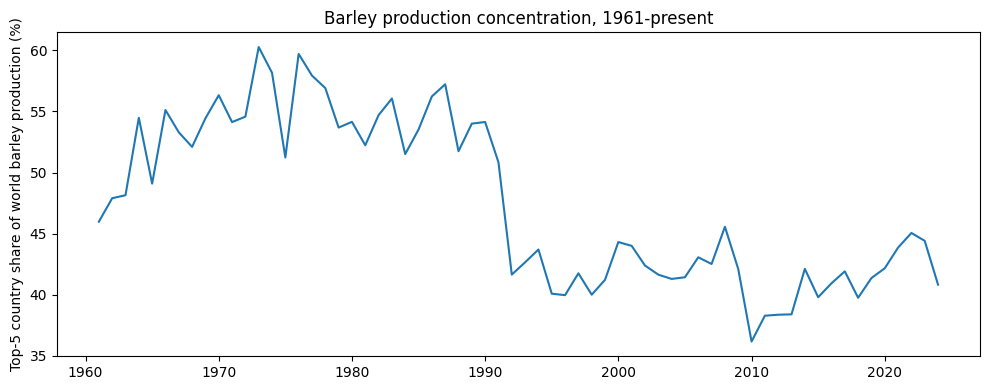

Latest top-5 share: 40.8%


In [8]:
# Full-history concentration trend (top-5 share of world production, year by year) — same metric
# as the original notebook's Section 4, recomputed here for Barley alone.
by_year_rank = barley_by_area_year.copy()
by_year_rank['rank'] = by_year_rank.groupby('Year')['production_t'].rank(ascending=False, method='min')

global_total_by_year = barley_by_area_year.groupby('Year')['production_t'].sum().reset_index(name='global_total')
top5_by_year = (by_year_rank[by_year_rank['rank'] <= 5]
                .groupby('Year')['production_t'].sum().reset_index(name='top5_total'))
concentration = top5_by_year.merge(global_total_by_year, on='Year')
concentration['top5_share_pct'] = concentration['top5_total'] / concentration['global_total'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(concentration['Year'], concentration['top5_share_pct'])
ax.set_ylabel('Top-5 country share of world barley production (%)')
ax.set_title('Barley production concentration, 1961-present')
plt.tight_layout(); plt.show()

print(f"Latest top-5 share: {concentration.sort_values('Year').iloc[-1]['top5_share_pct']:.1f}%")


## Section 3: Water stress (SDG 6.4.2) — bulk download + cleaning

Reuses the fixed download logic from the original notebook; adds the "latest available value per
country" resolution called for in Section 0's data principles.

In [10]:
# Section 3a: SDG bulk download
SDG_BULK = 'https://bulks-faostat.fao.org/production/SDG_BulkDownloads_E_All_Data_(Normalized).zip'
if not os.path.exists('sdgb_bulk.zip'):
    print('Downloading SDGB bulk file...')
    urllib.request.urlretrieve(SDG_BULK, 'sdgb_bulk.zip')

with zipfile.ZipFile('sdgb_bulk.zip') as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'Flags' not in n
                and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    sdgb_all = pd.read_csv(z.open(csv_name), encoding='latin-1', low_memory=False)
    flags_lookup = pd.read_csv(z.open('SDG_BulkDownloads_E_Flags.csv'), encoding='latin-1')

water_stress_all = sdgb_all[sdgb_all['Item Code'] == '24027-_T'].copy()  # headline SDG 6.4.2, no sub-breakdown
print(f'{len(water_stress_all):,} rows, {water_stress_all["Area Code"].nunique()} areas, '
      f'{water_stress_all["Year"].min()}-{water_stress_all["Year"].max()}')

official_flags = flags_lookup[flags_lookup[' Description'].str.contains('official|reported', case=False, na=False)]['Flag'].tolist()
print(f'Treating these flags as official: {official_flags}')


5,064 rows, 211 areas, 2000-2023
Treating these flags as official: ['A']


In [12]:
water_stress_all = water_stress_all.dropna(subset=['Value']).copy()
water_stress_all['is_official'] = water_stress_all['Flag'].isin(official_flags)

idx_latest = water_stress_all.groupby('Area Code')['Year'].idxmax()
water_stress_latest = water_stress_all.loc[idx_latest, ['Area', 'Area Code', 'Year', 'Value', 'Flag', 'is_official']]
water_stress_latest = water_stress_latest.rename(columns={'Year': 'ws_year', 'Value': 'water_stress_pct'})

# Ensure 'water_stress_pct' is numeric, coercing errors and dropping any resulting NaNs.
water_stress_latest['water_stress_pct'] = pd.to_numeric(water_stress_latest['water_stress_pct'], errors='coerce')
water_stress_latest = water_stress_latest.dropna(subset=['water_stress_pct']).copy()

water_stress_latest['water_stress_tier'] = pd.cut(
    water_stress_latest['water_stress_pct'],
    bins=CONFIG['water_stress_bins'], labels=CONFIG['water_stress_labels'], right=False)
water_stress_latest['is_stressed'] = water_stress_latest['water_stress_pct'] >= CONFIG['stress_threshold_pct']

print(f"Countries with any water-stress reading: {len(water_stress_latest)}")
print(water_stress_latest['water_stress_tier'].value_counts().sort_index().to_string())

Countries with any water-stress reading: 211
water_stress_tier
No stress        141
Low stress        30
Medium stress     15
High stress        8
Critical          17


## Section 4 — Step 1: Which major barley producers are water-stressed?

This is the central finding to validate.

In [13]:
# Join top producers to their latest water-stress reading. Area Code cast to str on both sides —
# same dtype discipline as Section 1c.
top_producers['Area Code'] = top_producers['Area Code'].astype(str)
water_stress_latest['Area Code'] = water_stress_latest['Area Code'].astype(str)

producer_exposure = top_producers.merge(
    water_stress_latest[['Area Code', 'ws_year', 'water_stress_pct', 'water_stress_tier', 'is_stressed', 'is_official']],
    on='Area Code', how='left')

producer_exposure['water_stress_tier'] = producer_exposure['water_stress_tier'].astype(object).fillna('No data')
producer_exposure['is_stressed'] = producer_exposure['is_stressed'].fillna(False)

cols = ['rank', 'Area', 'avg_production_t', 'pct_of_world', 'water_stress_pct', 'water_stress_tier', 'ws_year', 'is_official']
print(producer_exposure[cols].to_string(index=False))

n_stressed = producer_exposure['is_stressed'].sum()
share_stressed = producer_exposure.loc[producer_exposure['is_stressed'], 'pct_of_world'].sum()
print(f"\n{n_stressed} of the top {CONFIG['top_n_producers']} barley producers are water-stressed (>= "
      f"{CONFIG['stress_threshold_pct']}% withdrawal ratio), together accounting for "
      f"{share_stressed:.1f}% of world production.")


 rank                                                 Area  avg_production_t  pct_of_world  water_stress_pct water_stress_tier  ws_year  is_official
    1                                   Russian Federation      2.018684e+07     13.743114              4.16         No stress     2023         True
    2                                            Australia      1.257275e+07      8.559478              4.22         No stress     2023         True
    3                                               France      1.103273e+07      7.511034             20.57         No stress     2023         True
    4                                              Germany      1.093900e+07      7.447225             31.46        Low stress     2023        False
    5                                               Canada      9.011988e+06      6.135323              3.72         No stress     2023        False
    6                                             TÃ¼rkiye      8.600000e+06      5.854844             47.

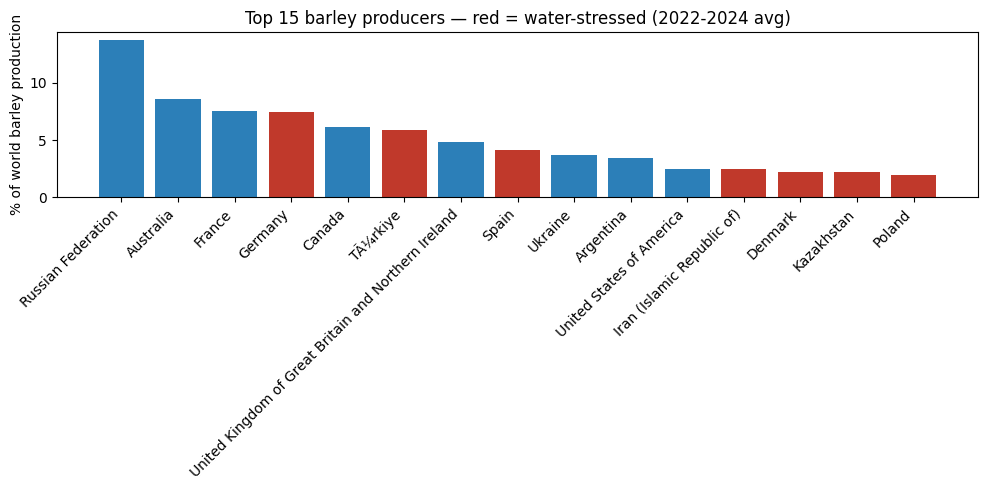

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = producer_exposure['is_stressed'].map({True: '#c0392b', False: '#2c7fb8'})
ax.bar(producer_exposure['Area'], producer_exposure['pct_of_world'], color=colors)
ax.set_ylabel('% of world barley production')
ax.set_title(f'Top {CONFIG["top_n_producers"]} barley producers — red = water-stressed ({trailing_years[0]}-{trailing_years[-1]} avg)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


## Section 5 — Step 2 setup: Detailed Trade Matrix bulk download

This file covers every commodity, every reporter-partner pair, every year — far bigger than
QCL/SDGB. We stream it in chunks and keep only Barley import rows, so memory stays bounded
regardless of the full file size.

In [15]:
# Section 5a: Trade Matrix bulk download
TM_BULK = 'https://bulks-faostat.fao.org/production/Trade_DetailedTradeMatrix_E_All_Data_(Normalized).zip'
if not os.path.exists('tm_bulk.zip'):
    print('Downloading Detailed Trade Matrix bulk file — this one is large, may take several minutes...')
    urllib.request.urlretrieve(TM_BULK, 'tm_bulk.zip')

with zipfile.ZipFile('tm_bulk.zip') as z:
    names = z.namelist()
    tm_csv_name = [n for n in names if n.endswith('.csv') and 'Flags' not in n
                   and 'ItemCodes' not in n and 'AreaCodes' not in n][0]
    print(f'Main data file: {tm_csv_name}')

    item_csv_candidates = [n for n in names if 'ItemCodes' in n]
    tm_item_codes = pd.read_csv(z.open(item_csv_candidates[0]), encoding='latin-1') if item_csv_candidates else None

    area_csv_candidates = [n for n in names if 'AreaCodes' in n]
    tm_area_codes = pd.read_csv(z.open(area_csv_candidates[0]), encoding='latin-1') if area_csv_candidates else area_codes


Main data file: Trade_DetailedTradeMatrix_E_All_Data_(Normalized).csv


In [16]:
# Section 5b: verify the Barley item code in the TRADE domain's own lookup — don't just assume it
# matches QCL's code (it does here, but that's worth confirming, not assuming).
if tm_item_codes is not None:
    tm_barley_matches = tm_item_codes[tm_item_codes['Item'].str.contains('Barley', case=False, na=False)][['Item Code', 'Item']]
    print(tm_barley_matches.to_string(index=False))
    tm_barley_code = int(tm_barley_matches.loc[tm_barley_matches['Item'].str.fullmatch('Barley', case=False), 'Item Code'].iloc[0])
else:
    tm_barley_code = CONFIG['crop_item_code']
print(f'Using TM Item Code {tm_barley_code} for Barley')


 Item Code                   Item
        44                 Barley
        48 Barley flour and grits
        46        Barley; pearled
        51 Beer of barley; malted
        47         Bran of barley
        45             Pot barley
Using TM Item Code 44 for Barley


In [ ]:
# Section 5c: stream the file in chunks, keep only Barley + Import Quantity rows. Reporter/partner
# column names are discovered from the header rather than hardcoded, since exact naming can vary
# slightly by FAOSTAT domain vintage.
with zipfile.ZipFile('tm_bulk.zip') as z:
    header = pd.read_csv(z.open(tm_csv_name), encoding='latin-1', nrows=0).columns.tolist()
print(header)

reporter_code_col = [c for c in header if 'Reporter' in c and 'Code' in c][0]
reporter_name_col = [c for c in header if 'Reporter' in c and 'Code' not in c][0]
partner_code_col  = [c for c in header if 'Partner' in c and 'Code' in c][0]
partner_name_col  = [c for c in header if 'Partner' in c and 'Code' not in c][0]
print(f'Reporter columns: {reporter_code_col} / {reporter_name_col}')
print(f'Partner columns:  {partner_code_col} / {partner_name_col}')

keep_cols = [reporter_code_col, reporter_name_col, partner_code_col, partner_name_col,
             'Item Code', 'Item', 'Element', 'Unit', 'Year', 'Value']

chunks = []
with zipfile.ZipFile('tm_bulk.zip') as z:
    reader = pd.read_csv(z.open(tm_csv_name), encoding='latin-1', low_memory=False,
                          usecols=keep_cols, chunksize=1_000_000)
    for i, chunk in enumerate(reader):
        filtered = chunk[(chunk['Item Code'] == tm_barley_code) & (chunk['Element'] == 'Import Quantity')]
        if len(filtered):
            chunks.append(filtered.copy())
        if i % 20 == 0:
            print(f'  ...scanned {(i + 1):,} chunks')

tm_barley_imports = pd.concat(chunks, ignore_index=True)
print(f'\nBarley import-quantity rows: {len(tm_barley_imports):,}')
print(f"Unit(s): {tm_barley_imports['Unit'].unique()}")


['Reporter Country Code', 'Reporter Country Code (M49)', 'Reporter Countries', 'Partner Country Code', 'Partner Country Code (M49)', 'Partner Countries', 'Item Code', 'Item Code (CPC)', 'Item', 'Element Code', 'Element', 'Year Code', 'Year', 'Unit', 'Value', 'Flag']
Reporter columns: Reporter Country Code / Reporter Countries
Partner columns:  Partner Country Code / Partner Countries
  ...scanned 1 chunks


In [ ]:
# Drop regional/continental aggregates on BOTH reporter and partner sides — a country "importing
# from World", or a supplier row that's actually a continent aggregate, would badly distort the
# supplier-concentration numbers in Section 6.
valid_codes_tm = set(tm_area_codes[tm_area_codes['Area Code'] < 5000]['Area Code'].astype(str))

tm_barley_imports = tm_barley_imports[
    tm_barley_imports[reporter_code_col].astype(str).isin(valid_codes_tm) &
    tm_barley_imports[partner_code_col].astype(str).isin(valid_codes_tm)
].copy()
print(f'After dropping aggregates on both sides: {len(tm_barley_imports):,} rows')


## Section 6 — Step 2: Supplier concentration & import dependency

For each importing country: how concentrated are its barley suppliers, and what share of its
imports comes from water-stressed suppliers?

In [ ]:
# Same trailing-average smoothing as production (Section 0 principle), applied to bilateral trade.
tm_latest_year = tm_barley_imports['Year'].max()
tm_trailing_years = list(range(tm_latest_year - CONFIG['trailing_avg_years'] + 1, tm_latest_year + 1))
print(f'Trade matrix trailing window: {tm_trailing_years} (latest year in file: {tm_latest_year})')

trade_trailing = (tm_barley_imports[tm_barley_imports['Year'].isin(tm_trailing_years)]
                   .groupby([reporter_code_col, reporter_name_col, partner_code_col, partner_name_col])['Value']
                   .mean().reset_index(name='avg_import_t'))
trade_trailing = trade_trailing[trade_trailing['avg_import_t'] > 0]

# Bring in each supplier's own water-stress tier (from Sections 3/4)
trade_trailing[partner_code_col] = trade_trailing[partner_code_col].astype(str)
trade_trailing = trade_trailing.merge(
    water_stress_latest[['Area Code', 'water_stress_pct', 'water_stress_tier', 'is_stressed']],
    left_on=partner_code_col, right_on='Area Code', how='left')
trade_trailing['water_stress_tier'] = trade_trailing['water_stress_tier'].astype(object).fillna('No data')
trade_trailing['is_stressed'] = trade_trailing['is_stressed'].fillna(False)

print(f'{trade_trailing[reporter_code_col].nunique()} importing countries, '
      f'{trade_trailing[partner_code_col].nunique()} distinct suppliers in the barley trade network')


In [ ]:
def summarize_importer(df):
    total = df['avg_import_t'].sum()
    df = df.assign(share=df['avg_import_t'] / total).sort_values('share', ascending=False)
    top = df.iloc[0]
    return pd.Series({
        'total_imports_t': total,
        'n_suppliers': len(df),
        'top_supplier': top[partner_name_col],
        'top_supplier_share_pct': top['share'] * 100,
        'hhi': (df['share'] ** 2).sum() * 10000,  # Herfindahl-Hirschman Index, 0-10000 scale
        'pct_from_stressed_suppliers': df.loc[df['is_stressed'], 'share'].sum() * 100,
        'pct_from_no_data_suppliers': df.loc[df['water_stress_tier'] == 'No data', 'share'].sum() * 100,
    })

import_exposure = (trade_trailing.groupby([reporter_code_col, reporter_name_col])
                    .apply(summarize_importer, include_groups=False).reset_index()
                    .rename(columns={reporter_name_col: 'importer'}))

import_exposure = import_exposure.sort_values('pct_from_stressed_suppliers', ascending=False).reset_index(drop=True)

print("Most import-exposed barley-buying countries (share of imports from water-stressed suppliers):")
print(import_exposure.head(CONFIG['top_n_importers_display'])
      [['importer', 'total_imports_t', 'n_suppliers', 'top_supplier', 'top_supplier_share_pct',
        'hhi', 'pct_from_stressed_suppliers']].to_string(index=False))


In [ ]:
top_exp = import_exposure.head(CONFIG['top_n_importers_display'])
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_exp['importer'], top_exp['pct_from_stressed_suppliers'], color='#c0392b')
ax.set_ylabel('% of barley imports from water-stressed suppliers')
ax.set_title('Most import-exposed barley-buying countries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


## Section 7 — Step 3: Prototype scenario — supply shock + diversification

One importing country, modeled end-to-end, to design the dashboard and AI brief before scaling to
additional countries (per the brief: "use this example to design the dashboard and AI-generated
resilience brief before scaling").

In [ ]:
# Default: the single most exposed importer from Section 6. Override manually to pick a different
# country for the prototype (e.g. one more familiar to the audience for a live demo).
SELECTED_IMPORTER = import_exposure.iloc[0]['importer']
print(f'Prototype country: {SELECTED_IMPORTER}')

supplier_mix = (trade_trailing[trade_trailing[reporter_name_col] == SELECTED_IMPORTER]
                [[partner_name_col, 'avg_import_t', 'water_stress_tier', 'is_stressed']]
                .rename(columns={partner_name_col: 'supplier'})
                .sort_values('avg_import_t', ascending=False).reset_index(drop=True))
supplier_mix['share_pct'] = supplier_mix['avg_import_t'] / supplier_mix['avg_import_t'].sum() * 100
print(supplier_mix.to_string(index=False))

# Shock target: the largest supplier that is ALSO water-stressed (falls back to the largest overall
# supplier if none of them are stressed).
stressed_suppliers = supplier_mix[supplier_mix['is_stressed']]
SHOCK_SUPPLIER = (stressed_suppliers.iloc[0]['supplier'] if len(stressed_suppliers)
                   else supplier_mix.iloc[0]['supplier'])
print(f'\nShock target: {SHOCK_SUPPLIER}')


In [ ]:
def simulate_shock(mix, supplier, pct_reduction, diversify=False):
    """
    Elasticity-1 assumption: a pct_reduction cut in `supplier`'s production is modeled as the same
    pct cut in what they export to this importer (Section 0/9 limitation — no substitution effects,
    no price response modeled).
    If diversify=True, the lost volume is reallocated proportionally across the importer's OTHER
    existing suppliers, in proportion to their current share, assuming unconstrained headroom
    (a stated simplification, see Section 9) — i.e. a sourcing-diversification response.
    """
    m = mix.copy()
    lost = m.loc[m['supplier'] == supplier, 'avg_import_t'].iloc[0] * pct_reduction
    m.loc[m['supplier'] == supplier, 'avg_import_t'] -= lost

    if diversify:
        others = m['supplier'] != supplier
        other_total = m.loc[others, 'avg_import_t'].sum()
        if other_total > 0:
            m.loc[others, 'avg_import_t'] += lost * (m.loc[others, 'avg_import_t'] / other_total)

    new_total = m['avg_import_t'].sum()
    baseline_total = mix['avg_import_t'].sum()
    gap_pct = (baseline_total - new_total) / baseline_total * 100
    pct_stressed_after = m.loc[m['is_stressed'], 'avg_import_t'].sum() / new_total * 100 if new_total > 0 else np.nan
    return {'gap_pct': gap_pct, 'pct_from_stressed_after': pct_stressed_after, 'mix': m}

scenario_results = []
for pct in [0.10, 0.20, 0.30]:
    no_div = simulate_shock(supplier_mix, SHOCK_SUPPLIER, pct, diversify=False)
    with_div = simulate_shock(supplier_mix, SHOCK_SUPPLIER, pct, diversify=True)
    scenario_results.append({
        'reduction_pct': int(pct * 100),
        'gap_no_diversification_pct': no_div['gap_pct'],
        'gap_with_diversification_pct': with_div['gap_pct'],
        'pct_from_stressed_no_div': no_div['pct_from_stressed_after'],
        'pct_from_stressed_with_div': with_div['pct_from_stressed_after'],
    })

scenario_df = pd.DataFrame(scenario_results)
print(scenario_df.to_string(index=False))


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(scenario_df['reduction_pct'], scenario_df['gap_no_diversification_pct'], marker='o', label='No diversification')
ax.plot(scenario_df['reduction_pct'], scenario_df['gap_with_diversification_pct'], marker='o', label='With diversification')
ax.set_xlabel(f'{SHOCK_SUPPLIER} production cut (%)')
ax.set_ylabel(f"{SELECTED_IMPORTER}'s resulting barley supply gap (%)")
ax.set_title(f'Prototype scenario: {SELECTED_IMPORTER} sourcing from {SHOCK_SUPPLIER}')
ax.legend()
plt.tight_layout(); plt.show()


## Section 8: AI-generated resilience brief

Summarizes the scenario, key risks, possible actions, and analytical limitations for
`SELECTED_IMPORTER`. Uses Claude via the Anthropic API when a key is available; falls back to a
deterministic template otherwise, so the notebook still runs end to end without one.

In [ ]:
# Structured summary — everything the brief is allowed to reference, nothing it has to invent.
brief_input = {
    'importer': SELECTED_IMPORTER,
    'total_barley_imports_t': float(supplier_mix['avg_import_t'].sum()),
    'n_suppliers': int(len(supplier_mix)),
    'top_suppliers': supplier_mix.head(5)[['supplier', 'share_pct', 'water_stress_tier']].to_dict('records'),
    'baseline_pct_from_stressed_suppliers': float(
        import_exposure.loc[import_exposure['importer'] == SELECTED_IMPORTER, 'pct_from_stressed_suppliers'].iloc[0]),
    'shock_supplier': SHOCK_SUPPLIER,
    'shock_supplier_water_stress_tier': supplier_mix.loc[supplier_mix['supplier'] == SHOCK_SUPPLIER, 'water_stress_tier'].iloc[0],
    'scenarios': scenario_df.to_dict('records'),
    'analysis_years': {
        'production_window': trailing_years,
        'trade_window': tm_trailing_years,
    },
    'limitations': [
        "FAOSTAT does not separate brewing barley from feed/food barley — this covers total barley trade.",
        "Water-stress values are each country's latest available SDG 6.4.2 reading, not a single fixed "
        "year, because reporting is patchy across countries.",
        "Scenario assumes a 1:1 production-cut-to-export-cut elasticity, with no price response.",
        "Diversification scenario assumes unconstrained headroom at alternative suppliers.",
        "Exposure measures vulnerability, not a prediction that any country will run out of water or "
        "stop producing barley.",
    ],
}
print(json.dumps(brief_input, indent=2, default=str)[:2000])


In [ ]:
# Optional — only needed for the Claude-written version of the brief below; the fallback template
# works without it. Uncomment in Colab:
# !pip install -q anthropic
# import os
# os.environ['ANTHROPIC_API_KEY'] = 'sk-...'   # prefer Colab's secrets manager over hardcoding this


In [ ]:
def _fallback_brief(d):
    top_lines = '\n'.join(
        f"  - {s['supplier']}: {s['share_pct']:.1f}% of imports ({s['water_stress_tier']})"
        for s in d['top_suppliers'])
    scen_lines = '\n'.join(
        f"  - {s['reduction_pct']}% cut at {d['shock_supplier']}: "
        f"{s['gap_no_diversification_pct']:.1f}% supply gap unmanaged, "
        f"{s['gap_with_diversification_pct']:.1f}% gap if diversified"
        for s in d['scenarios'])
    limits = '\n'.join(f"  - {l}" for l in d['limitations'])
    return textwrap.dedent(f"""
    ## Barley water-risk resilience brief: {d['importer']}

    **Scenario.** {d['importer']} imports an average of {d['total_barley_imports_t']:,.0f} tonnes of
    barley per year (trade years {d['analysis_years']['trade_window'][0]}-{d['analysis_years']['trade_window'][-1]})
    from {d['n_suppliers']} suppliers. {d['baseline_pct_from_stressed_suppliers']:.1f}% of that volume
    currently comes from suppliers classified as water-stressed (SDG 6.4.2 withdrawal ratio >= 25%).

    **Top suppliers:**
    {top_lines}

    **Key risk.** {d['shock_supplier']} ({d['shock_supplier_water_stress_tier']}) is the modeled shock
    target. A production cut there ripples through {d['importer']}'s supply as follows:
    {scen_lines}

    **Possible actions.** Diversifying away from concentrated, water-stressed suppliers materially
    closes the modeled supply gap at every reduction level tested above. Priorities: (1) identify and
    pre-qualify alternate suppliers with lower water-stress exposure before a shock occurs, not during
    one; (2) monitor {d['shock_supplier']}'s SDG 6.4.2 trend and domestic production reports; (3) treat
    supplier concentration — not just water stress — as its own risk factor.

    **Analytical limitations:**
    {limits}
    """).strip()


def generate_resilience_brief(brief_input, model='claude-sonnet-4-6'):
    """Try Claude via the Anthropic API (needs ANTHROPIC_API_KEY in the environment); fall back to a
    deterministic template if the package or key isn't available, so this cell always produces output."""
    try:
        import anthropic
        api_key = os.environ.get('ANTHROPIC_API_KEY')
        if not api_key:
            raise RuntimeError('ANTHROPIC_API_KEY not set')
        client = anthropic.Anthropic(api_key=api_key)
        prompt = (
            "Write a concise resilience brief (scenario, key risks, possible actions, and analytical "
            "limitations) for a beverage-industry sustainability team, using ONLY the structured data "
            "below. Do not invent numbers not present in the data. Markdown, under 350 words.\n\n"
            + json.dumps(brief_input, indent=2, default=str)
        )
        resp = client.messages.create(
            model=model, max_tokens=900,
            messages=[{'role': 'user', 'content': prompt}])
        return ''.join(b.text for b in resp.content if b.type == 'text')
    except Exception as e:
        print(f'[Falling back to template brief — {e}]')
        return _fallback_brief(brief_input)


brief_text = generate_resilience_brief(brief_input)
display(Markdown(brief_text))


## Section 9: Limitations & next steps (not yet done)

- Scale Section 7's prototype scenario across all/most of Section 6's top exposed importers, not
  just `SELECTED_IMPORTER` — this notebook deliberately builds one example first (brief's Step 3).
- Turn Sections 4/6/7 into the interactive dashboard described in the proposed solution
  (importer/supplier/reduction-% pickers) — a notebook can't do the "test what-if scenarios"
  interactivity justice; a Streamlit/dashboarding pass is the natural next step.
- Trade data lags production data by 1-2 years at FAOSTAT — `tm_trailing_years` and `trailing_years`
  will rarely line up exactly; decide with the team whether that's acceptable or whether trade
  should be forced onto the same window as production.
- Water-stress values mix source years across countries (Section 0's principle) — revisit if the
  team wants strict year-comparability instead of latest-available-per-country.
- The diversification scenario has no capacity cap on alternate suppliers — a country can't always
  just export more. A next pass could bound reallocation by each alternate supplier's own spare
  production headroom.
- No price modeling — a real supply shock changes price, which changes both demand and which
  alternate suppliers become economically viable, not just which are physically available.
- `generate_resilience_brief()` needs `pip install anthropic` and `ANTHROPIC_API_KEY` set to use
  Claude; without it, the notebook still runs end-to-end on the template fallback — worth knowing
  before a live demo.
